In [ ]:
import pandas as pd
import numpy as np

data = [['John', 28, 'Male'],
        ['Kate', 23, 'Female'],
        ['David', 31, 'Male'],
        ['Emily', 27, 'Female']]
columns = ['Name', 'Age', 'Gender']
df = pd.DataFrame(data, columns=columns)

print(df)

In [ ]:
print(df.values)
print(df.columns)
print(df.index)

In [ ]:
print(df["Name"])

In [ ]:
data = {
    "2015": [9904312, 3448737, 2890451, 2466052],
    "2010": [9631482, 3393191, 2632035, 2431774],
    "2005": [9762546, 3512547, 2517680, 2456016],
    "2000": [9853972, 3655437, 2466338, 2473990],
    "지역": ["수도권", "경상권", "수도권", "경상권"],
    "2010-2015 증가율": [0.0283, 0.0163, 0.0982, 0.0141]
}
columns = ["지역", "2015", "2010", "2005", "2000", "2010-2015 증가율"]
index = ["서울", "부산", "인천", "대구"]
df = pd.DataFrame(data, index=index, columns=columns)

df

In [ ]:
df.info()

In [ ]:
pd.set_option('display.float_format', '{:3f}'.format)
print(df.describe())

In [ ]:
df.index.name = "도시"
df.columns.name = "특성"
df.name = "인구증가표"
df

In [ ]:
import pandas as pd

grade = {
    "국어": [100, 80, 70, 90, 90],
    "수학": [70, 60, 100, 80, 90],
    "영어": [80, 50, 90, 80, 90],
    "사회": [90, 90, 70, 60, 80],
    "과학": [100, 80, 70, 80, 90],
}

name = ["짱구", "철수", "훈이", "유리", "맹구"]
index = ["국어", "수학", "영어", "사회", "과학"]

df1 = pd.DataFrame(grade, columns=index, index = name)
df1

In [ ]:
df1.describe()

In [ ]:
import pandas as pd

data = {
    "이름": ["홍길동", "전우치", "심청이", "철수", "영희"],
    "국어": [95, 90, 85, 93, 87],
    "영어": [90, 87, 93, 94, 89],
    "수학": [73, 95, 87, 89, 93],
}

columns = ["이름", "국어", "영어", "수학"]
index = ["1번", "2번", "3번", "4번", "5번"]

df_ex = pd.DataFrame(data, index=index, columns=columns)
print(df_ex)

df_ex['평균'] = df_ex[['국어', '영어', '수학']].mean(axis=1).round(2)  # 각 행의 평균을 계산하고 소수점 두 자리로 반올림
print(df_ex)

In [ ]:
df["2010-2015 증가율"] = df["2010-2015 증가율"] * 100
df

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. 시드 고정
np.random.seed(0)
tf.random.set_seed(0)

# 2. 데이터 로드 및 분할
data = np.loadtxt("Data/pima-indians-diabetes.csv", delimiter=',', dtype=np.float32)

x_train = data[:700, 0:8]
y_train = data[:700, [8]]

x_test = data[700:, 0:8]
y_test = data[700:, [8]] # [오류 수정] y_test로 지정

# 3. 데이터 스케일링 (특성 표준화 - 성능 향상의 핵심!)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test) # test는 transform만 적용

# 4. 모델 구축 (은닉층 activation을 relu로 변경)
model = Sequential([
    Input(shape=(8,)),
    Dense(12, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

# 5. 옵티마이저 설정 (학습률 조정 가능)
# 기본값 0.001이 가장 무난하며, 필요시 0.01이나 0.0005 등으로 변경 테스트
custom_adam = Adam(learning_rate=0.001) 

model.compile(loss='binary_crossentropy', optimizer=custom_adam, metrics=['binary_accuracy'])

# 6. 조기 종료(EarlyStopping) 설정
# val_loss가 30번 동안 개선되지 않으면 학습을 자동 중단하고 가장 좋은 상태의 가중치를 복원
early_stopping = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

# 7. 모델 학습 (validation_data 추가)
history = model.fit(
    x_train_scaled, y_train,
    validation_data=(x_test_scaled, y_test),
    epochs=500, # EarlyStopping이 있으므로 크게 잡아도 안전함
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

# 8. 최종 평가 (Train이 아닌 Test 데이터로 평가해야 진짜 정확도임)
train_loss, train_acc = model.evaluate(x_train_scaled, y_train, verbose=0)
test_loss, test_acc = model.evaluate(x_test_scaled, y_test, verbose=0)

print(f"\n[결과 분석]")
print(f"최적 학습 종료 에폭: {len(history.history['loss'])}")
print(f"훈련 데이터 정확도(Train Acc) : {train_acc:.4f}")
print(f"검증 데이터 정확도(Test Acc)  : {test_acc:.4f}")

# 9. Loss 시각화를 통한 판단
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation (Test) Loss')
plt.title('Loss Curve for Finding Optimal Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd

df = pd.read_csv('Data/pima-indians-diabetes.csv',
                 names = ["pregnant", "plasma","pressure", "thickness", "insulin", "BMI", "pedigree", "age", "class"])

print(df.head(5))

   pregnant  plasma  pressure  thickness  insulin   BMI  pedigree  age  class
0         6     148        72         35        0  33.6     0.627   50      1
1         1      85        66         29        0  26.6     0.351   31      0
2         8     183        64          0        0  23.3     0.672   32      1
3         1      89        66         23       94  28.1     0.167   21      0
4         0     137        40         35      168  43.1     2.288   33      1


In [6]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pregnant   768 non-null    int64  
 1   plasma     768 non-null    int64  
 2   pressure   768 non-null    int64  
 3   thickness  768 non-null    int64  
 4   insulin    768 non-null    int64  
 5   BMI        768 non-null    float64
 6   pedigree   768 non-null    float64
 7   age        768 non-null    int64  
 8   class      768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [7]:
print(df.describe())

         pregnant      plasma    pressure   thickness     insulin         BMI  \
count  768.000000  768.000000  768.000000  768.000000  768.000000  768.000000   
mean     3.845052  120.894531   69.105469   20.536458   79.799479   31.992578   
std      3.369578   31.972618   19.355807   15.952218  115.244002    7.884160   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      1.000000   99.000000   62.000000    0.000000    0.000000   27.300000   
50%      3.000000  117.000000   72.000000   23.000000   30.500000   32.000000   
75%      6.000000  140.250000   80.000000   32.000000  127.250000   36.600000   
max     17.000000  199.000000  122.000000   99.000000  846.000000   67.100000   

         pedigree         age       class  
count  768.000000  768.000000  768.000000  
mean     0.471876   33.240885    0.348958  
std      0.331329   11.760232    0.476951  
min      0.078000   21.000000    0.000000  
25%      0.243750   24.000000    0.000000  
50%   

In [9]:
print(df[['pregnant', 'class']].groupby(['pregnant'], as_index = False).
      mean().sort_values(by='pregnant', ascending = True))

    pregnant     class
0          0  0.342342
1          1  0.214815
2          2  0.184466
3          3  0.360000
4          4  0.338235
5          5  0.368421
6          6  0.320000
7          7  0.555556
8          8  0.578947
9          9  0.642857
10        10  0.416667
11        11  0.636364
12        12  0.444444
13        13  0.500000
14        14  1.000000
15        15  1.000000
16        17  1.000000


<Axes: >

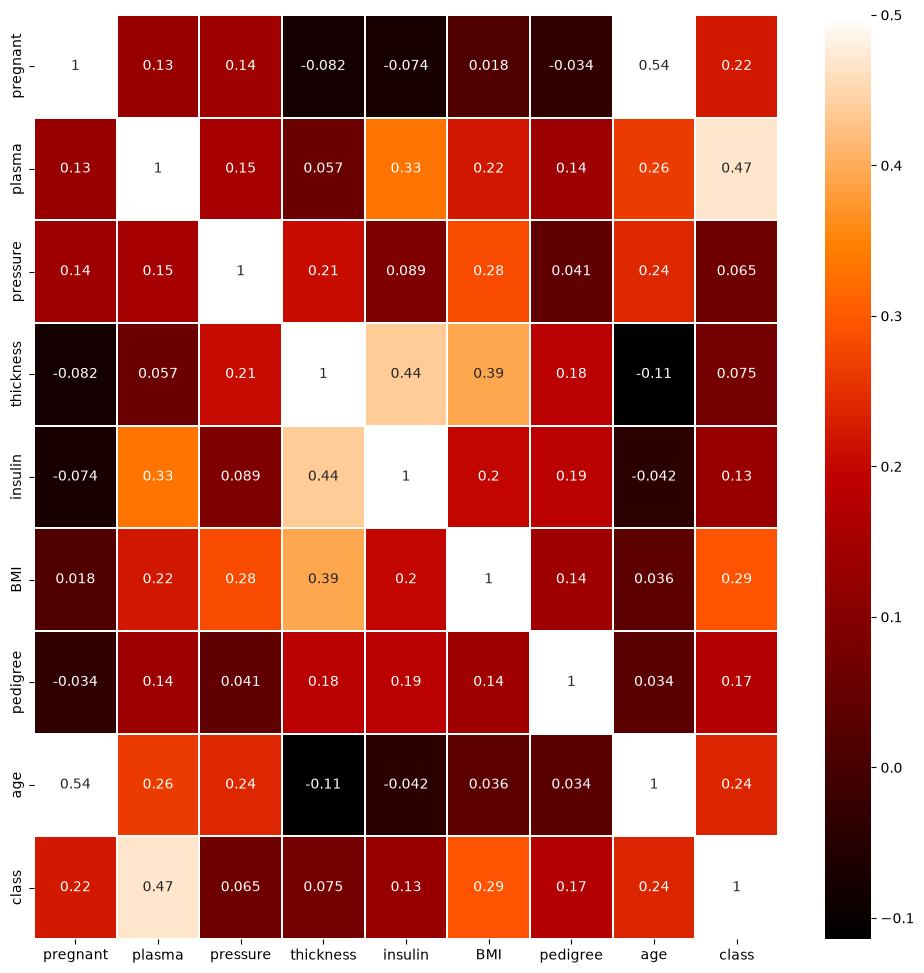

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,12))
sns.heatmap(df.corr(), linewidths = 0.1, vmax = 0.5, cmap = plt.cm.gist_heat, linecolor = 'white', annot = True)

In [14]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

seed = 0
np.random.seed(seed)
tf.random.set_seed(seed)

X = df.iloc[:, 0:8].values
Y = df.iloc[:, [8]].values

model = Sequential()
model.add(Input(shape = (8, )))
model.add(Dense(12, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

model.fit(X, Y, epochs = 200, batch_size = 10)

accuracy = model.evaluate(X, Y)[1]
print("\n Accuracy: %4f" % accuracy)

Epoch 1/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4036 - loss: 7.3120  
Epoch 2/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5052 - loss: 1.2065
Epoch 3/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5221 - loss: 0.8248
Epoch 4/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5911 - loss: 0.7415
Epoch 5/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6315 - loss: 0.7057
Epoch 6/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6445 - loss: 0.6853
Epoch 7/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6523 - loss: 0.6726
Epoch 8/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6536 - loss: 0.6631
Epoch 9/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6602 - loss: 0.6573
Epoch 10/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6628 - loss: 0.6519
Epoch 11/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6602 - loss: 0.6486
Epoch 12/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accurac

   sepal length  sepal width  petal length  petal width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa


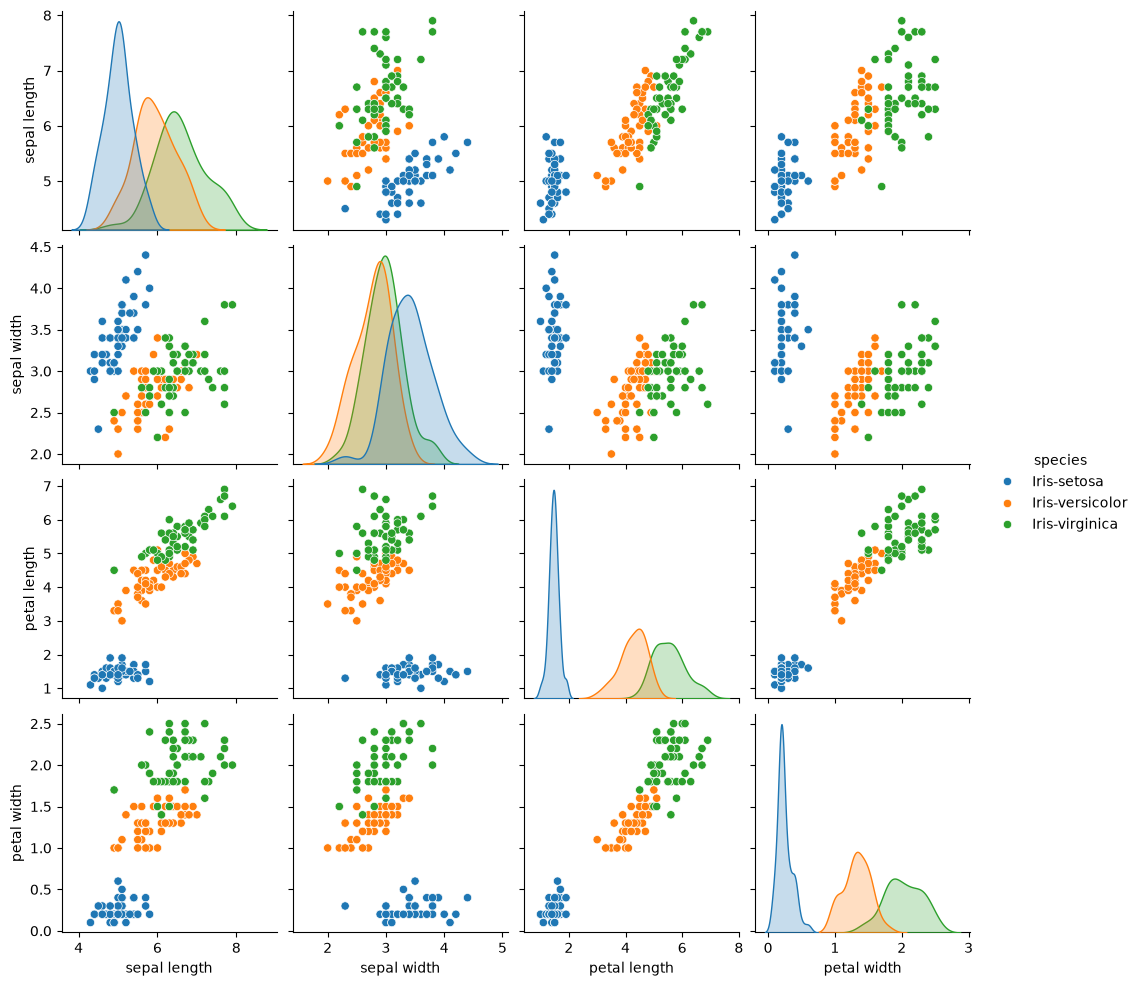

In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Input
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("Data/iris.csv", 
                   names = ["sepal length", "sepal width", "petal length", "petal width", "species"])

print(df.head())

sns.pairplot(df, hue ='species')
plt.show()

In [2]:
#Object를 순서로 바꿀 수 있음(Iris-setosa = 0, ... = 1 순서로)
from sklearn.preprocessing import LabelEncoder

dataset = df.values

x = dataset[:, 0:4].astype(float)
y_obj = dataset[:, 4]

e = LabelEncoder()
e.fit(y_obj)
y = e.transform(y_obj)

#활성화 함수를 적용하려면 y값이 숫자 0과 1로 이루어져야 함
#원핫 인코딩으로 변화하는 코드
y_encoded = tf.keras.utils.to_categorical(y)

In [3]:
model = Sequential()
model.add(Input(shape = (4,)))
model.add(Dense(16, activation= 'relu'))
model.add(Dense(8, activation= 'relu'))
model.add(Dense(3, activation= 'softmax'))

model.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(x, y_encoded, epochs=300, batch_size=16)

accuracy = model.evaluate(x, y_encoded)[1]
print("\n Accuracy: %4f" % accuracy)

Epoch 1/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6467 - loss: 0.9602  
Epoch 2/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6333 - loss: 0.9136 
Epoch 3/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5600 - loss: 0.8885 
Epoch 4/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6600 - loss: 0.8582 
Epoch 5/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5600 - loss: 0.8300 
Epoch 6/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5067 - loss: 0.8033 
Epoch 7/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5133 - loss: 0.7747 
Epoch 8/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5200 - loss: 0.7453 
Epoch 9/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6600 - loss: 0.7208 
Epoch 10/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6667 - loss: 0.6973 
Epoch 11/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6667 - loss: 0.6727 
Epoch 12/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step